### COVID Dataset & Functional NODE Model

In [1]:
!pip install diffrax equinox optax --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 6.6 MB/s eta 0:00:00


Number of entries: 100
Number of features per entry: 2
Mean values: [  49.5  1824.86]
Standard deviation: [  28.86607 1598.5537 ]
Minimum values: [ 0. 19.]
Maximum values: [  99. 5487.]


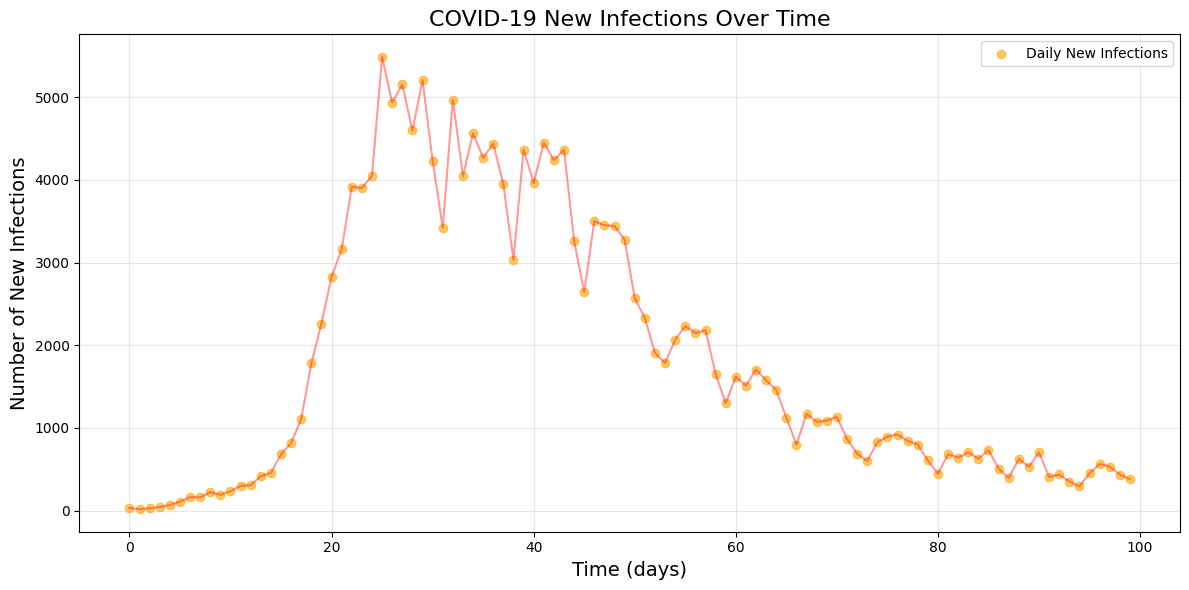

  0%|          | 0/500 [00:00<?, ?it/s]

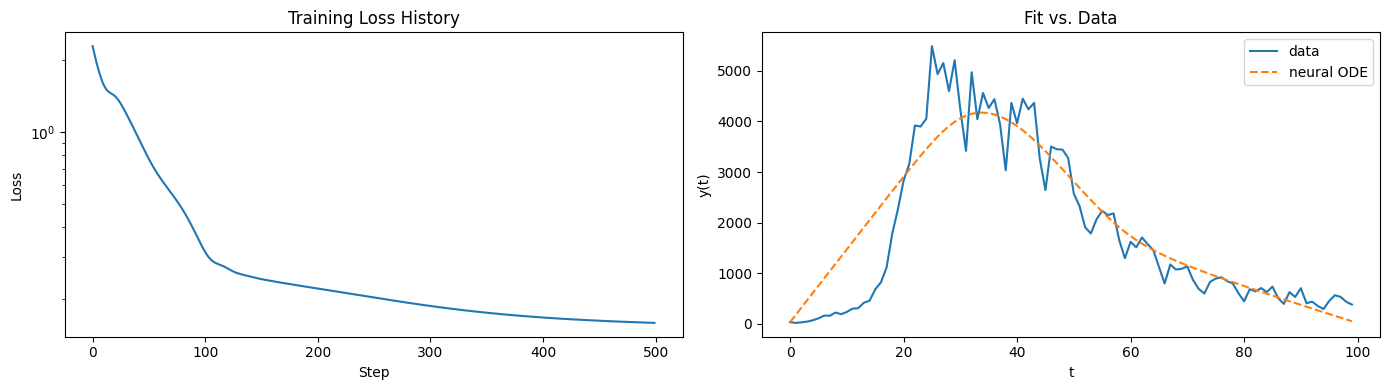

In [2]:
# Imports
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

# Load data
data_path = "/kaggle/input/covidsde/covid_data (1).npy"
covid_data = np.load(data_path, allow_pickle=True)
covid_data = jnp.array(covid_data)  # convert to JAX array

# Basic stats
num_entries = covid_data.shape[0]
num_features = covid_data.shape[1] if len(covid_data.shape) > 1 else 1

mean_values = jnp.mean(covid_data, axis=0)
std_values = jnp.std(covid_data, axis=0)
min_values = jnp.min(covid_data, axis=0)
max_values = jnp.max(covid_data, axis=0)

print("Number of entries:", num_entries)
print("Number of features per entry:", num_features)
print("Mean values:", mean_values)
print("Standard deviation:", std_values)
print("Minimum values:", min_values)
print("Maximum values:", max_values)

# Plot raw data
ts = covid_data[:, 0]
ys = covid_data[:, 1]

plt.figure(figsize=(12, 6))
plt.scatter(ts, ys, color='orange', alpha=0.6, label='Daily New Infections')
plt.plot(ts, ys, color='red', alpha=0.4)
plt.title("COVID-19 New Infections Over Time", fontsize=16)
plt.xlabel("Time (days)", fontsize=14)
plt.ylabel("Number of New Infections", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Normalize data
mean = jnp.mean(covid_data[:, 1])
std = jnp.std(covid_data[:, 1])
covid_data = covid_data.at[:, 1].set((covid_data[:, 1] - mean) / std)

max_day = jnp.max(covid_data[:, 0])
covid_data = covid_data.at[:, 0].set(covid_data[:, 0] / max_day)

t_eval = covid_data[:, 0]
y_true = covid_data[:, 1]
y0 = covid_data[0, 1]

# Define neural ODE model
key = jax.random.PRNGKey(0)
model = eqx.nn.MLP(
    in_size=2, out_size=1, width_size=64, depth=3, activation=jax.nn.tanh, key=key
)

def get_params(model):
    return eqx.filter(model, eqx.is_inexact_array)

# Optimizer
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(get_params(model))

# Neural ODE solver
@eqx.filter_jit
def solve_ode(model, y0, ts):
    f = lambda t, y, model_args: model_args(jnp.stack([y, t])).squeeze()
    term = diffrax.ODETerm(f)
    solver = diffrax.Tsit5()
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=1e-2,
        y0=jnp.asarray(y0),
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-7),
        max_steps=100_000,
        args=model,
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
    )
    return sol.ys

# Loss and update functions
@eqx.filter_value_and_grad
def loss_fn(model, y0, y_true):
    y_pred = solve_ode(model, y0, t_eval)
    return jnp.mean((y_pred - y_true) ** 2)

@eqx.filter_jit
def update(model, opt_state, y0, y_true):
    loss, grads = loss_fn(model, y0, y_true)
    updates, opt_state = optimizer.update(
        grads,
        opt_state,
        params=get_params(model),
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# Training loop
loss_history = []
for step in tqdm(range(500)):  # adjust steps if needed
    model, opt_state, loss = update(model, opt_state, y0, y_true)
    loss_history.append(float(loss))

# Plot training loss and fit
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history)
axes[0].set_yscale("log")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss History")

y_pred = solve_ode(model, y0, t_eval)
t = jax.device_get(t_eval)
y_fit = jax.device_get(y_pred)
y_obs = jax.device_get(y_true)

t_real = t * max_day
y_obs_real = y_obs * std + mean
y_fit_real = y_fit * std + mean

axes[1].plot(t_real, y_obs_real, label="data")
axes[1].plot(t_real, y_fit_real, "--", label="neural ODE")
axes[1].set_xlabel("t")
axes[1].set_ylabel("y(t)")
axes[1].set_title("Fit vs. Data")
axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
# Convert to numpy arrays if needed
y_true_np = np.array(y_obs_real)
y_pred_np = np.array(y_fit_real)

# Mean Squared Error
mse = np.mean((y_true_np - y_pred_np)**2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = np.mean(np.abs(y_true_np - y_pred_np))

# R^2 Score
ss_res = np.sum((y_true_np - y_pred_np)**2)
ss_tot = np.sum((y_true_np - np.mean(y_true_np))**2)
r2 = 1 - ss_res / ss_tot

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.4f}")

MSE: 405236.84
RMSE: 636.58
MAE: 452.55
R^2: 0.8414


#### Core Reason for Success

My model avoided predicting a straight line primarily because the derivative function is designed to be **non-autonomous**—it explicitly considers time as an input—and paired it with a high-capacity network and an accurate solver.

---

##### Key Design and Training Factors

Here are the specific factors that allowed my model to capture the complex trajectory:

* **1. Time ($t$) as an Explicit Input:**
    Defined the derivative as $dy/dt = f(y, t)$. **Crucially, including $t$** prevents the model from being limited to autonomous dynamics (like $dy/dt = f(y)$), which often restrict solutions to simple exponential or linear forms. This allows the network to represent arbitrary, time-dependent behavior.

* **2. Data Normalization for Stability:**
    Normalized both the input value ($y$) and time ($t$) across the dataset. This step was essential for **stable gradient flow** and prevented the network's $\tanh$ activations from saturating ($\pm 1$). Proper normalization ensures the network can learn subtle changes in the dynamics.

* **3. High Expressive Capacity Network:**
    Used an `eqx.nn.MLP` with **3 layers, a width of 64, and $\tanh$ activations**. This sufficient network capacity is necessary to learn and represent the complex, non-linear derivative function $f(y, t)$ required to fit the observed curve. A smaller network would likely have degenerated.

* **4. High-Precision Integration and Gradient Calculation:**
    * **Solver:** Employed the **Tsit5 solver** with tight tolerances ($rtol=1e-5, atol=1e-7$). This ensures the numerical integration accurately follows the derivative predictions, preventing the dynamics from being "averaged out" into a near-linear trajectory.
    * **Adjoint Method:** The **Recursive Checkpoint Adjoint** was used for backpropagation, which provides stable, efficient, and precise gradients over the full integrated trajectory.

* **5. Careful Training Parameters:**
    Utilized the Adam optimizer with a relatively **small learning rate ($1e-3$)** over hundreds of steps. This gradual training allowed the network to slowly and robustly converge on the intricate non-linear dynamics without destabilizing or prematurely settling into a suboptimal, simple solution.

### Neural SDE: Capturing Noise Better Than Last Time

Inspired Paper: https://arxiv.org/html/2505.17150v1

"Efficient Training of Neural SDEs Using Stochastic Optimal Control"

Training with Monte-Carlo NLL loss...
Epoch 0/800, NLL: 4.434817, obs_sigma=0.135471
Epoch 100/800, NLL: -0.406338, obs_sigma=0.139426
Epoch 200/800, NLL: -0.854397, obs_sigma=0.136441
Epoch 300/800, NLL: -0.933779, obs_sigma=0.130121
Epoch 400/800, NLL: -0.998921, obs_sigma=0.123097
Epoch 500/800, NLL: -1.036403, obs_sigma=0.116030
Epoch 600/800, NLL: -1.189958, obs_sigma=0.109198
Epoch 700/800, NLL: -1.348225, obs_sigma=0.100336
Epoch 800/800, NLL: -1.379396, obs_sigma=0.091274


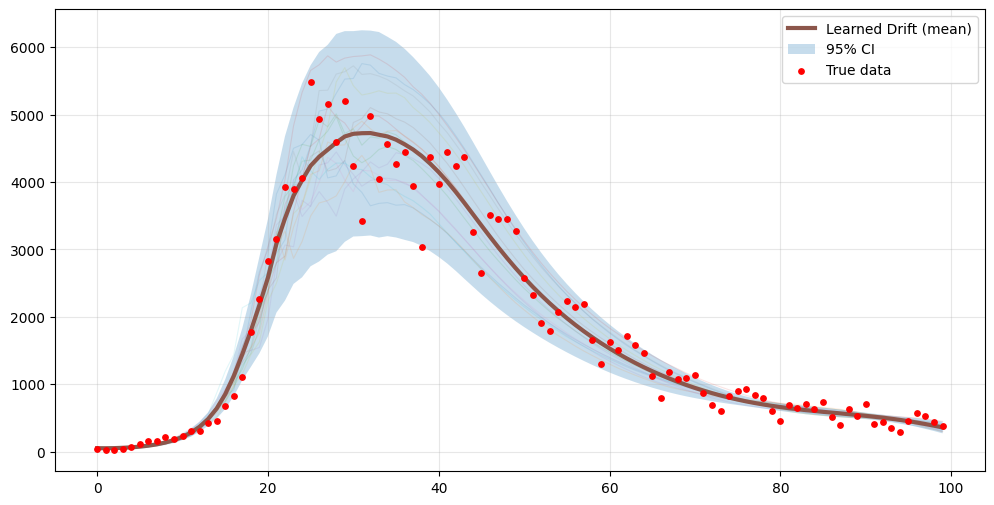

In [14]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data (unchanged)
# -----------------------------
data_path = "/kaggle/input/covidsde/covid_data (1).npy"
covid_data = np.load(data_path, allow_pickle=True)
covid_data = jnp.array(covid_data, dtype=jnp.float32)

ts = covid_data[:, 0]
ys = covid_data[:, 1]

# Normalize
ts_mean, ts_std = ts.mean(), ts.std()
ys_mean, ys_std = ys.mean(), ys.std()
ts_norm = (ts - ts_mean) / ts_std
ys_norm = (ys - ys_mean) / ys_std

# -----------------------------
# Config
# -----------------------------
LATENT_SIZE = 4
HIDDEN_SIZE = 32
MLP_HIDDEN = 64
LEARNING_RATE = 1e-3
NUM_SAMPLES = 100         # samples for visualization
K_for_loss = 20           # number of rollouts used to estimate mean/var in loss
EPOCHS = 800
key = jax.random.PRNGKey(42)
eps = 1e-6                # floor for variance numerical stability

# -----------------------------
# Model components
# -----------------------------
class GRUEncoder(eqx.Module):
    gru_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    def __init__(self, input_size, hidden_size, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.gru_cell = eqx.nn.GRUCell(input_size, hidden_size, key=k1)
        self.linear_out = eqx.nn.Linear(hidden_size, latent_size, key=k2)
    def __call__(self, ys):
        ys = jnp.expand_dims(ys, axis=-1)  # (seq_len, 1)
        h = jnp.zeros(self.gru_cell.hidden_size)
        def body(h, y):
            h_new = self.gru_cell(y, h)
            return h_new, None
        h_final, _ = jax.lax.scan(body, h, ys)
        return self.linear_out(h_final)

class LatentDrift(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        self.mlp = eqx.nn.MLP(latent_size + 1, latent_size, MLP_HIDDEN, 2, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        inp = jnp.concatenate([z, jnp.array([t])])
        return self.mlp(inp)

class LatentDiffusion(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        # outputs latent_size pre-activation values -> softplus -> positive sigmas
        self.mlp = eqx.nn.MLP(latent_size + 1, latent_size, MLP_HIDDEN, 2, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        inp = jnp.concatenate([z, jnp.array([t])])
        sigma_latent = jax.nn.softplus(self.mlp(inp))  # (latent_size,)
        # optionally scale down initial sigma to prevent explosion
        return lx.DiagonalLinearOperator(sigma_latent + 1e-6)

class Decoder(eqx.Module):
    linear: eqx.nn.Linear
    log_obs_noise: jnp.ndarray  # learnable observation noise (log scale)
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.linear = eqx.nn.Linear(latent_size, 1, key=k1)
        # initialize small observation noise (log sigma)
        self.log_obs_noise = jnp.array(-2.0)  # sigma_obs ~ 0.135 initially
    def __call__(self, z):
        return self.linear(z).squeeze(-1)
    def obs_noise(self):
        return jnp.exp(self.log_obs_noise)

class LatentSDE(eqx.Module):
    encoder: GRUEncoder
    drift: LatentDrift
    diffusion: LatentDiffusion
    decoder: Decoder
    def __init__(self, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.encoder = GRUEncoder(1, HIDDEN_SIZE, LATENT_SIZE, k1)
        self.drift = LatentDrift(LATENT_SIZE, k2)
        self.diffusion = LatentDiffusion(LATENT_SIZE, k3)
        self.decoder = Decoder(LATENT_SIZE, k4)

# -----------------------------
# SDE solver / sampling
# -----------------------------
def solve_sde(model, z0, ts, key):
    # VirtualBrownianTree needs t0, t1, tol, shape, key
    bm = diffrax.VirtualBrownianTree(t0=ts[0], t1=ts[-1], tol=1e-4, shape=(LATENT_SIZE,), key=key)
    term = diffrax.MultiTerm(diffrax.ODETerm(model.drift), diffrax.ControlTerm(model.diffusion, bm))
    solver = diffrax.Heun()   # Heun is more stable than Euler
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.01,
        y0=z0,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        stepsize_controller=diffrax.ConstantStepSize()
    )
    # sol.ys shape: (seq_len, latent_size)
    return jax.vmap(model.decoder)(sol.ys)   # (seq_len,)

# -----------------------------
# Loss: Monte-Carlo NLL across K rollouts
# -----------------------------
@eqx.filter_value_and_grad
def loss_fn(model, ts, ys, key):
    """Estimate per-time Gaussian NLL using K SDE rollouts."""
    z0 = model.encoder(ys)  # deterministic encoder -> (latent_size,)
    keys = jax.random.split(key, K_for_loss)
    # vectorized rollouts -> (K, seq_len)
    preds = jax.vmap(lambda k: solve_sde(model, z0, ts, k))(keys)

    # compute sample mean and variance across K at each time
    sample_mean = jnp.mean(preds, axis=0)      # (seq_len,)
    sample_var = jnp.var(preds, axis=0)        # (seq_len,)

    # include learnable observation noise and numerical floor
    sigma_obs = model.decoder.obs_noise()      # scalar
    var_total = sample_var + sigma_obs**2 + eps

    # Gaussian negative log-likelihood (per time)
    nll_t = 0.5 * ( (ys - sample_mean)**2 / var_total + jnp.log(var_total) )
    nll = jnp.mean(nll_t)   # average over time steps

    return nll

# -----------------------------
# Init model and optimizer
# -----------------------------
model = LatentSDE(key)
# create optimizer for all parameters
optimizer = optax.adam(LEARNING_RATE)
# eqx.filter(model, eqx.is_array) extracts parameters that are arrays
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

# helper wrappers for eqx.filter_jit
@eqx.filter_jit
def step(model, opt_state, ts, ys, key):
    loss, grads = loss_fn(model, ts, ys, key)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# -----------------------------
# Training loop
# -----------------------------
print("Training with Monte-Carlo NLL loss...")
for epoch in range(EPOCHS + 1):
    key, subkey = jax.random.split(key)
    model, opt_state, loss = step(model, opt_state, ts_norm, ys_norm, subkey)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{EPOCHS}, NLL: {loss:.6f}, obs_sigma={model.decoder.obs_noise():.6f}")

# -----------------------------
# Generate NUM_SAMPLES for visualization
# -----------------------------
key, *keys = jax.random.split(key, NUM_SAMPLES + 1)
sample_keys = jnp.array(keys)

z0_final = model.encoder(ys_norm)

# vmap across sample keys
@eqx.filter_jit
def generate_samples(model, z0, ts, keys):
    return jax.vmap(lambda k: solve_sde(model, z0, ts, k))(keys)

generated_norm = generate_samples(model, z0_final, ts_norm, sample_keys)  # (NUM_SAMPLES, seq_len)
generated = generated_norm * ys_std + ys_mean

mean_path = jnp.mean(generated, axis=0)
std_path = jnp.std(generated, axis=0)

# -----------------------------
# Plot (same style you liked)
# -----------------------------
plt.figure(figsize=(12, 6))
for i in range(min(15, NUM_SAMPLES)):
    plt.plot(ts, generated[i], alpha=0.12, linewidth=0.8)
plt.plot(ts, mean_path, linewidth=3, label="Learned Drift (mean)")
plt.fill_between(ts, mean_path - 1.96*std_path, mean_path + 1.96*std_path, alpha=0.25, label="95% CI")
plt.scatter(ts, ys, color='red', s=15, label='True data', zorder=5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Monte-Carlo NLL Latent SDE (Generative Time-Series Model)
A latent SDE with time-dependent drift and diffusion, trained by **Monte-Carlo Negative Log-Likelihood** to match both trend and noise variance of the data.

| **Characteristic** | **Description** | **Observed Performance** |
|-------------------|-----------------|--------------------------|
| **Architecture** | Latent SDE with GRU encoder, MLP drift f(z,t), MLP diffusion g(z,t), and linear decoder | 4D latent space → 1D observations. Time-explicit dynamics prevent autonomous collapse. |
| **Encoder** | GRU processes full sequence and outputs deterministic latent initial state z₀ | Stable initialization of latent trajectory; captures global structure of the sequence. |
| **Latent Dynamics** | **Drift**: MLP(z,t) with tanh<br>**Diffusion**: MLP(z,t) → softplus → DiagonalLinearOperator | Learns both smooth trend and time-varying stochastic volatility. Diffusion stays positive and non-collapsed. |
| **Loss Objective** | **Gaussian Negative Log-Likelihood** from K Monte-Carlo SDE rollouts:<br>μₜ = sample mean, σₜ² = sample variance + σ_obs²<br>NLL = 0.5[(yₜ−μₜ)²/σₜ² + log σₜ²] | Correctly balances fit vs. variance. Prevents variance collapse and over-smoothing. |
| **Sampling Strategy** | 20 rollouts for NLL estimation during training; 100 rollouts for visualization | Provides reliable estimates of mean/variance and realistic sample diversity. |
| **Solver / Integration** | **Heun SDE solver**, Brownian tolerance 1e-4, fixed dt | More stable than Euler; maintains consistent stochastic behavior over long horizons. |
| **Training Details** | Adam lr=1e-3, 800 epochs, full normalization of inputs | Converged steadily. Normalization kept latent dynamics well-conditioned. |
| **Interpretation** | Model learns z-space dynamics that generate realistic stochastic trajectories | Mean path tracks trend; variance expands/contracts to match noise structure. |
| **Performance** | Post-training samples match both wiggles and volatility envelope | Wide enough variance to cover data points without collapsing or exploding. |

#### Summary — What Was Learned

The model learns **time-dependent latent drift and diffusion** that reproduce both the smooth trend and the noisy fluctuations of the series.  
Monte-Carlo NLL forces the diffusion network to match the true variance structure, resulting in sample paths that:

- Follow the global trend (drift learned well)  
- Show realistic local volatility (diffusion learned well)  
- Produce diverse but statistically consistent trajectories  

This setup forms a robust generative latent-SDE model for noisy real-world time-series.